**Fractal Codec**--

---


This is a google colab version for the encoder and decoder for cloud gpu testing of the encoder and decoder

**Environment Setup**

In [ ]:
!wget -q https://developer.nvidia.com/downloads/assets/tools/secure/nsight-systems/2026_2/NsightSystems-linux-cli-public-2026.2.1.210-3763964.deb
!apt-get install -y ./NsightSystems-linux-cli-public-2026.2.1.210-3763964.deb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'nsight-systems-cli-2026.2.1' instead of './NsightSystems-linux-cli-public-2026.2.1.210-3763964.deb'
The following NEW packages will be installed:
  nsight-systems-cli-2026.2.1
0 upgraded, 1 newly installed, 0 to remove and 33 not upgraded.
Need to get 0 B/211 MB of archives.
After this operation, 0 B of additional disk space will be used.
Get:1 /content/NsightSystems-linux-cli-public-2026.2.1.210-3763964.deb nsight-systems-cli-2026.2.1 amd64 2026.2.1.210-262137639646v0 [211 MB]
Selecting previously unselected package nsight-systems-cli-2026.2.1.
(Reading database ... 127332 files and directories currently installed.)
Preparing to unpack .../NsightSystems-linux-cli-public-2026.2.1.210-3763964.deb ...
Unpacking nsight-systems-cli-2026.2.1 (2026.2.1.210-262137639646v0) ...
Setting up nsight-systems-cli-2026.2.1 (2026.2.1.210-262137639646v0) ...
update-alternatives: using /opt/

In [ ]:
!nvidia-smi
!nvcc --version

Sat Oct  3 17:43:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**common.h**

In [ ]:
%%writefile common.h
#pragma once
#include <cstdint>
#include <cuda_runtime.h>


// Thresholds for the Hybrid Architecture
const float TEMPORAL_SKIP_THRESHOLD = 0.005f; // If difference is less than this, do nothing
const float MAX_PIXEL_DRIFT = 0.03f;
const float UI_4x4_THRESHOLD        = 0.0005f; // Must be nearly perfect to stay at 4x4
const float MAX_PIXEL_ERROR         = 0.05f;   // Catch sharp text edges

struct HybridCode {
    uint16_t x;
    uint16_t y;
    uint16_t domain_idx;
    uint8_t depth;       // 0=32x32, 1=16x16, 2=8x8, 3=4x4, 4=Raw(2x2)
    uint8_t isometry_id;
    float contrast;
    float brightness;
    float raw_pixels[4]; // Used if depth == 4
};

Overwriting common.h


**domain creater**

In [ ]:
%%writefile domain_builder.cuh
#pragma once
#include "common.h"
#include <cuda_runtime.h>

// ============================================================
// Domain Pool Builder (Hybrid Downsampling)
// ============================================================

// Downsamples 8x8 regions into 4x4 blocks (16 pixels)
__global__ void build8x8DownsampledPoolKernel(const float* d_img, float* d_pool, int width) {
    int dom_x = blockIdx.x * blockDim.x + threadIdx.x;
    int dom_y = blockIdx.y * blockDim.y + threadIdx.y;
    int domains_per_row = width / 8;

    if (dom_x < domains_per_row && dom_y < (width / 8)) {
        int dom_idx = dom_y * domains_per_row + dom_x;
        int start_x = dom_x * 8;
        int start_y = dom_y * 8;

        for (int p = 0; p < 16; p++) {
            int px = p % 4;
            int py = p / 4;
            float avg = 0.0f;
            for (int dy = 0; dy < 2; dy++) {
                for (int dx = 0; dx < 2; dx++) {
                    avg += d_img[(start_y + py * 2 + dy) * width + (start_x + px * 2 + dx)];
                }
            }
            d_pool[dom_idx * 16 + p] = avg * 0.25f;
        }
    }
}

// Downsamples 4x4 regions into 2x2 micro-blocks (4 pixels)
__global__ void build4x4DownsampledPoolKernel(const float* d_img, float* d_pool, int width) {
    int dom_x = blockIdx.x * blockDim.x + threadIdx.x;
    int dom_y = blockIdx.y * blockDim.y + threadIdx.y;
    int domains_per_row = width / 4;

    if (dom_x < domains_per_row && dom_y < (width / 4)) {
        int dom_idx = dom_y * domains_per_row + dom_x;
        int start_x = dom_x * 4;
        int start_y = dom_y * 4;

        for (int p = 0; p < 4; p++) {
            int px = p % 2;
            int py = p / 2;
            float avg = 0.0f;
            for (int dy = 0; dy < 2; dy++) {
                for (int dx = 0; dx < 2; dx++) {
                    avg += d_img[(start_y + py * 2 + dy) * width + (start_x + px * 2 + dx)];
                }
            }
            d_pool[dom_idx * 4 + p] = avg * 0.25f;
        }
    }
}

// Host function to allocate memory and launch the kernels
void buildDomainPools(const float* d_curr_frame, float** d_domains_8x8, float** d_domains_4x4) {
    int d8_count = (IMAGE_WIDTH / 8) * (IMAGE_HEIGHT / 8);
    int d4_count = (IMAGE_WIDTH / 4) * (IMAGE_HEIGHT / 4);

    cudaMalloc(d_domains_8x8, d8_count * 16 * sizeof(float));
    cudaMalloc(d_domains_4x4, d4_count * 4 * sizeof(float));

    dim3 block(16, 16);
    dim3 grid8((IMAGE_WIDTH / 8 + 15) / 16, (IMAGE_HEIGHT / 8 + 15) / 16);
    dim3 grid4((IMAGE_WIDTH / 4 + 15) / 16, (IMAGE_HEIGHT / 4 + 15) / 16);

    build8x8DownsampledPoolKernel<<<grid8, block>>>(d_curr_frame, *d_domains_8x8, IMAGE_WIDTH);
    build4x4DownsampledPoolKernel<<<grid4, block>>>(d_curr_frame, *d_domains_4x4, IMAGE_WIDTH);
    cudaDeviceSynchronize();
}

Overwriting domain_builder.cuh


**Encoder**

In [ ]:
%%writefile temporal_encoder.cu
#include "common.h"
#include <cuda_runtime.h>
#include <nvtx3/nvToolsExt.h>
#include <iostream>
#include <vector>
#include <fstream>
#include <math.h>
#include <cstdlib>

const float BAILOUT_42DB_ERROR = 0.001009f;

__global__ void build8x8DownsampledPoolKernel(const float* d_img, float* d_pool, int width, int height) {
    int dom_x = blockIdx.x * blockDim.x + threadIdx.x;
    int dom_y = blockIdx.y * blockDim.y + threadIdx.y;
    int domains_per_row = width / 8;
    if (dom_x < domains_per_row && dom_y < (height / 8)) {
        int dom_idx = dom_y * domains_per_row + dom_x;
        int start_x = dom_x * 8; int start_y = dom_y * 8;
        for (int p = 0; p < 16; p++) {
            float avg = 0.0f;
            for (int dy = 0; dy < 2; dy++) {
                for (int dx = 0; dx < 2; dx++) {
                    avg += d_img[(start_y + (p/4) * 2 + dy) * width + (start_x + (p%4) * 2 + dx)];
                }
            }
            d_pool[dom_idx * 16 + p] = avg * 0.25f;
        }
    }
}

void buildDomainPools(const float* d_curr_frame, float** d_domains_8x8, int width, int height) {
    int d8_count = (width / 8) * (height / 8);
    cudaMalloc(d_domains_8x8, d8_count * 16 * sizeof(float));
    dim3 block(16, 16);
    dim3 grid8((width / 8 + 15) / 16, (height / 8 + 15) / 16);
    build8x8DownsampledPoolKernel<<<grid8, block>>>(d_curr_frame, *d_domains_8x8, width, height);
    cudaDeviceSynchronize();
}

__device__ __forceinline__ int getIsoPixel(int px, int py, int dim, int iso) {
    int nx = px, ny = py;
    switch(iso) {
        case 0: nx = px; ny = py; break;
        case 1: nx = py; ny = (dim-1)-px; break;
        case 2: nx = (dim-1)-px; ny = (dim-1)-py; break;
        case 3: nx = (dim-1)-py; ny = px; break;
        case 4: nx = (dim-1)-px; ny = py; break;
        case 5: nx = py; ny = px; break;
        case 6: nx = px; ny = (dim-1)-py; break;
        case 7: nx = (dim-1)-py; ny = (dim-1)-px; break;
    }
    return ny * dim + nx;
}

__device__ bool searchMotionVector(
    cudaTextureObject_t tex_curr, cudaTextureObject_t tex_prev,
    int rx, int ry, int size, float threshold_sad, float max_drift,
    int width, int height,
    int& best_dx, int& best_dy
) {
    float best_diff = threshold_sad;
    bool found = false;
    for (int dy = -8; dy <= 8; dy++) {
        for (int dx = -8; dx <= 8; dx++) {
            if (dx == 0 && dy == 0) continue;
            if (rx + dx < 0 || rx + dx + size > width ||
                ry + dy < 0 || ry + dy + size > height) continue;

            float diff = 0.0f; float current_max = 0.0f; bool invalid = false;
            for (int py = 0; py < size; py++) {
                for (int px = 0; px < size; px++) {
                    float curr = tex1Dfetch<float>(tex_curr, (ry + py) * width + (rx + px));
                    float prev = tex1Dfetch<float>(tex_prev, (ry + dy + py) * width + (rx + dx + px));
                    float px_diff = fabsf(curr - prev);
                    diff += px_diff; current_max = fmaxf(current_max, px_diff);
                    if (diff >= best_diff || current_max >= max_drift) { invalid = true; break; }
                }
                if (invalid) break;
            }
            if (!invalid && diff < best_diff) {
                best_diff = diff; best_dx = dx; best_dy = dy; found = true;
            }
        }
    }
    return found;
}

__global__ void hybridTemporalEncodeCooperativeQuadtree(
    cudaTextureObject_t tex_curr, cudaTextureObject_t tex_prev, cudaTextureObject_t tex_dom8,
    HybridCode* d_output_codes, int* d_output_counter, int total_domains_4x4_pass,
    int width, int height
) {
    __shared__ float s_diff[64];
    __shared__ float s_max_diff[64];
    __shared__ float s_flags_16[4];
    __shared__ float s_flags_8[16];

    int tx = threadIdx.x; int ty = threadIdx.y; int tid = ty * 8 + tx;
    int bx = blockIdx.x * 32; int by = blockIdx.y * 32;
    int rx = bx + tx * 4; int ry = by + ty * 4;

    if (rx >= width || ry >= height) return;

    float my_diff = 0.0f; float my_max = 0.0f;
    for (int py = 0; py < 4; py++) {
        for (int px = 0; px < 4; px++) {
            int g_idx = (ry + py) * width + (rx + px);
            float curr = tex1Dfetch<float>(tex_curr, g_idx);
            float prev = tex1Dfetch<float>(tex_prev, g_idx);
            float err = fabsf(curr - prev);
            my_diff += err; my_max = fmaxf(my_max, err);
        }
    }
    s_diff[tid] = my_diff; s_max_diff[tid] = my_max;
    __syncthreads();

    if (tid == 0) {
        float total_32 = 0; float max_32 = 0;
        for (int i = 0; i < 64; i++) {
            total_32 += s_diff[i]; max_32 = fmaxf(max_32, s_max_diff[i]);
        }
        float thresh = TEMPORAL_SKIP_THRESHOLD * 64.0f;
        if (total_32 < thresh && max_32 < MAX_PIXEL_DRIFT) {
            int out_idx = atomicAdd(d_output_counter, 1);
            d_output_codes[out_idx] = {(uint16_t)bx, (uint16_t)by, 0xFFFF, 0, 0, 0, 0, {0}};
            s_diff[0] = -1.0f;
        } else {
            s_diff[0] = 1.0f;
        }
    }
    __syncthreads();
    if (s_diff[0] < 0.0f) return;

    int q_idx = (ty / 4) * 2 + (tx / 4);
    int leader_16 = (ty / 4) * 32 + (tx / 4) * 4;
    if (tid == leader_16) {
        float total_16 = 0; float max_16 = 0;
        for (int dy = 0; dy < 4; dy++) {
            for (int dx = 0; dx < 4; dx++) {
                int idx = (ty/4*4 + dy)*8 + (tx/4*4 + dx);
                total_16 += s_diff[idx]; max_16 = fmaxf(max_16, s_max_diff[idx]);
            }
        }
        float thresh = TEMPORAL_SKIP_THRESHOLD * 16.0f;
        int sub_x = bx + (tx/4)*16; int sub_y = by + (ty/4)*16;

        if (total_16 < thresh && max_16 < MAX_PIXEL_DRIFT) {
            int out_idx = atomicAdd(d_output_counter, 1);
            d_output_codes[out_idx] = {(uint16_t)sub_x, (uint16_t)sub_y, 0xFFFF, 1, 0, 0, 0, {0}};
            s_flags_16[q_idx] = -1.0f;
        } else {
            int dx, dy;
            if (searchMotionVector(tex_curr, tex_prev, sub_x, sub_y, 16, thresh, MAX_PIXEL_DRIFT, width, height, dx, dy)) {
                int out_idx = atomicAdd(d_output_counter, 1);
                d_output_codes[out_idx] = {(uint16_t)sub_x, (uint16_t)sub_y, 0xFFFE, 1, 0, (float)dx, (float)dy, {0}};
                s_flags_16[q_idx] = -1.0f;
            } else {
                s_flags_16[q_idx] = 1.0f;
            }
        }
    }
    __syncthreads();
    if (s_flags_16[q_idx] < 0.0f) return;

    int e_idx = (ty / 2) * 4 + (tx / 2);
    int leader_8 = (ty / 2) * 16 + (tx / 2) * 2;
    if (tid == leader_8) {
        float total_8 = 0; float max_8 = 0;
        for (int dy = 0; dy < 2; dy++) {
            for (int dx = 0; dx < 2; dx++) {
                int idx = (ty/2*2 + dy)*8 + (tx/2*2 + dx);
                total_8 += s_diff[idx]; max_8 = fmaxf(max_8, s_max_diff[idx]);
            }
        }
        float thresh = TEMPORAL_SKIP_THRESHOLD * 4.0f;
        int sub_x = bx + (tx/2)*8; int sub_y = by + (ty/2)*8;

        if (total_8 < thresh && max_8 < MAX_PIXEL_DRIFT) {
            int out_idx = atomicAdd(d_output_counter, 1);
            d_output_codes[out_idx] = {(uint16_t)sub_x, (uint16_t)sub_y, 0xFFFF, 2, 0, 0, 0, {0}};
            s_flags_8[e_idx] = -1.0f;
        } else {
            int dx, dy;
            if (searchMotionVector(tex_curr, tex_prev, sub_x, sub_y, 8, thresh, MAX_PIXEL_DRIFT, width, height, dx, dy)) {
                int out_idx = atomicAdd(d_output_counter, 1);
                d_output_codes[out_idx] = {(uint16_t)sub_x, (uint16_t)sub_y, 0xFFFE, 2, 0, (float)dx, (float)dy, {0}};
                s_flags_8[e_idx] = -1.0f;
            } else {
                s_flags_8[e_idx] = 1.0f;
            }
        }
    }
    __syncthreads();
    if (s_flags_8[e_idx] < 0.0f) return;

    if (my_diff < TEMPORAL_SKIP_THRESHOLD && my_max < MAX_PIXEL_DRIFT) {
        int out_idx = atomicAdd(d_output_counter, 1);
        d_output_codes[out_idx] = {(uint16_t)rx, (uint16_t)ry, 0xFFFF, 3, 0, 0, 0, {0}};
        return;
    }

    int dx, dy;
    if (searchMotionVector(tex_curr, tex_prev, rx, ry, 4, TEMPORAL_SKIP_THRESHOLD, MAX_PIXEL_DRIFT, width, height, dx, dy)) {
        int out_idx = atomicAdd(d_output_counter, 1);
        d_output_codes[out_idx] = {(uint16_t)rx, (uint16_t)ry, 0xFFFE, 3, 0, (float)dx, (float)dy, {0}};
        return;
    }

    float best_error = 1e30f; HybridCode best_code = {0}; float R[16]; float sum_R = 0.0f;
    for (int i = 0; i < 16; i++) {
        R[i] = tex1Dfetch<float>(tex_curr, (ry + (i/4)) * width + (rx + (i%4))); sum_R += R[i];
    }

    for (int dom_idx = 0; dom_idx < total_domains_4x4_pass; dom_idx += 2) {
        for (int iso = 0; iso < 8; iso+=2) {
            float sum_D = 0.0f, sum_D2 = 0.0f, sum_RD = 0.0f;
            for (int p = 0; p < 16; p++) {
                int mapped = getIsoPixel(p%4, p/4, 4, iso);
                float d_val = tex1Dfetch<float>(tex_dom8, (dom_idx * 16) + mapped);
                sum_D += d_val; sum_D2 += d_val * d_val; sum_RD += R[p] * d_val;
            }
            float den = (16.0f * sum_D2) - (sum_D * sum_D);
            float contrast = (den > 0.0001f) ? ((16.0f * sum_RD) - (sum_R * sum_D)) / den : 0.0f;
            contrast = fminf(fmaxf(contrast, -0.99f), 0.99f);
            float brightness = (sum_R - contrast * sum_D) / 16.0f;
            float error = 0.0f; float max_px_error = 0.0f;

            for (int p = 0; p < 16; p++) {
                int mapped = getIsoPixel(p%4, p/4, 4, iso);
                float diff = fabsf((contrast * tex1Dfetch<float>(tex_dom8, (dom_idx * 16) + mapped)) + brightness - R[p]);
                error += diff * diff; max_px_error = fmaxf(max_px_error, diff);
            }
            if (max_px_error > MAX_PIXEL_ERROR) error = 1e30f;
            if (error < best_error) {
                best_error = error; best_code = {(uint16_t)rx, (uint16_t)ry, (uint16_t)dom_idx, 3, (uint8_t)iso, contrast, brightness, {0}};
                if (best_error < BAILOUT_42DB_ERROR) goto BAILOUT_NODE;
            }
        }
    }

BAILOUT_NODE:
    if (best_error < UI_4x4_THRESHOLD) {
        int out_idx = atomicAdd(d_output_counter, 1);
        d_output_codes[out_idx] = best_code;
        return;
    }

    int res_dx = 0, res_dy = 0;
    searchMotionVector(tex_curr, tex_prev, rx, ry, 4, 1e30f, 1e30f, width, height, res_dx, res_dy);

    HybridCode res_code = {(uint16_t)rx, (uint16_t)ry, 0xFFFD, 3, 0, (float)res_dx, (float)res_dy, {0}};
    int8_t* residual_payload = reinterpret_cast<int8_t*>(res_code.raw_pixels);

    for (int py = 0; py < 4; py++) {
        for (int px = 0; px < 4; px++) {
            float curr = tex1Dfetch<float>(tex_curr, (ry + py) * width + (rx + px));
            float prev = tex1Dfetch<float>(tex_prev, (ry + res_dy + py) * width + (rx + res_dx + px));

            float diff = (curr - prev) * 255.0f;

            // Allow the full 8-bit difference (-128 to +127) to capture sharp 3D edges
            int quantized = max(-128, min(127, (int)roundf(diff)));

            residual_payload[py * 4 + px] = (int8_t)quantized;
        }
    }

    int out_idx = atomicAdd(d_output_counter, 1);
    d_output_codes[out_idx] = res_code;
}

bool loadRawImage(const char* filename, std::vector<float>& image_data, int total_pixels) {
    std::ifstream file(filename, std::ios::binary | std::ios::ate);
    if (!file) return false;
    std::streamsize size = file.tellg();
    file.seekg(0, std::ios::beg);
    image_data.resize(total_pixels);
    file.read(reinterpret_cast<char*>(image_data.data()), size);
    return true;
}

cudaTextureObject_t createLinearTexture(float* d_ptr, int size_in_floats) {
    cudaResourceDesc resDesc = {};
    resDesc.resType = cudaResourceTypeLinear;
    resDesc.res.linear.devPtr = d_ptr;
    resDesc.res.linear.desc = cudaCreateChannelDesc<float>();
    resDesc.res.linear.sizeInBytes = size_in_floats * sizeof(float);
    cudaTextureDesc texDesc = {};
    texDesc.readMode = cudaReadModeElementType;
    cudaTextureObject_t tex = 0;
    cudaCreateTextureObject(&tex, &resDesc, &texDesc, nullptr);
    return tex;
}

int main(int argc, char** argv) {
    if (argc < 5) {
        std::cerr << "Usage: ./encoder <prev.bin> <curr.bin> <width> <height>\n";
        return 1;
    }
    const char* prev_file = argv[1];
    const char* curr_file = argv[2];
    int width = std::atoi(argv[3]);
    int height = std::atoi(argv[4]);
    int total_pixels = width * height;

    cudaFree(0);

    std::vector<float> h_prev_frame, h_curr_frame;
    loadRawImage(prev_file, h_prev_frame, total_pixels);
    loadRawImage(curr_file, h_curr_frame, total_pixels);

    float *d_curr_frame, *d_prev_frame;
    cudaMalloc(&d_curr_frame, total_pixels * sizeof(float));
    cudaMalloc(&d_prev_frame, total_pixels * sizeof(float));
    cudaMemcpy(d_curr_frame, h_curr_frame.data(), total_pixels * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_prev_frame, h_prev_frame.data(), total_pixels * sizeof(float), cudaMemcpyHostToDevice);

    cudaTextureObject_t tex_curr = createLinearTexture(d_curr_frame, total_pixels);
    cudaTextureObject_t tex_prev = createLinearTexture(d_prev_frame, total_pixels);

    float *d_domains_8x8;
    buildDomainPools(d_curr_frame, &d_domains_8x8, width, height);

    int d8_count = (width / 8) * (height / 8);
    cudaTextureObject_t tex_dom8 = createLinearTexture(d_domains_8x8, d8_count * 16);

    int max_possible_codes = (total_pixels / 4);
    HybridCode* d_output_codes;
    int* d_output_counter;
    cudaMalloc(&d_output_codes, max_possible_codes * sizeof(HybridCode));
    cudaMalloc(&d_output_counter, sizeof(int));
    cudaMemset(d_output_counter, 0, sizeof(int));

    std::cout << "Starting Encoder at " << width << "x" << height << "...\n";

    dim3 threads(8, 8);
    dim3 grid((width + 31) / 32, (height + 31) / 32);

    hybridTemporalEncodeCooperativeQuadtree<<<grid, threads>>>(
        tex_curr, tex_prev, tex_dom8,
        d_output_codes, d_output_counter,
        (width/8)*(height/8), width, height
    );
    cudaDeviceSynchronize();

    int h_output_counter = 0;
    cudaMemcpy(&h_output_counter, d_output_counter, sizeof(int), cudaMemcpyDeviceToHost);

    std::vector<HybridCode> h_output_codes(h_output_counter);
    cudaMemcpy(h_output_codes.data(), d_output_codes, h_output_counter * sizeof(HybridCode), cudaMemcpyDeviceToHost);

    std::ofstream outfile("encoded_temporal.bin", std::ios::binary);
    outfile.write(reinterpret_cast<const char*>(h_output_codes.data()), h_output_counter * sizeof(HybridCode));
    outfile.close();

    std::cout << "Success! Wrote " << h_output_counter << " codes.\n";

    cudaDestroyTextureObject(tex_curr); cudaDestroyTextureObject(tex_prev);
    cudaDestroyTextureObject(tex_dom8);
    cudaFree(d_curr_frame); cudaFree(d_prev_frame);
    cudaFree(d_domains_8x8);
    cudaFree(d_output_codes); cudaFree(d_output_counter);
    return 0;
}

Overwriting temporal_encoder.cu


**Decoder**

In [ ]:
%%writefile temporal_decoder.cu
#include "common.h"
#include <cuda_runtime.h>
#include <iostream>
#include <vector>
#include <fstream>
#include <math.h>
#include <cstdlib>

__device__ __forceinline__ int getIsoPixel(int px, int py, int dim, int iso) {
    int nx = px, ny = py;
    switch(iso) {
        case 0: nx = px; ny = py; break;
        case 1: nx = py; ny = (dim-1)-px; break;
        case 2: nx = (dim-1)-px; ny = (dim-1)-py; break;
        case 3: nx = (dim-1)-py; ny = px; break;
        case 4: nx = (dim-1)-px; ny = py; break;
        case 5: nx = py; ny = px; break;
        case 6: nx = px; ny = (dim-1)-py; break;
        case 7: nx = (dim-1)-py; ny = (dim-1)-px; break;
    }
    return ny * dim + nx;
}

__global__ void hybridTemporalDecodeQuadtreeKernel(
    const HybridCode* d_codes, const float* d_prev, const float* d_in_iter, float* d_out_iter, int total_codes, int width, int height
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= total_codes) return;

    HybridCode code = d_codes[idx];
    int rx = code.x; int ry = code.y;
    int size = 32 >> code.depth;

    // TEMPORAL BLOCKS: Strictly read from immutable d_prev
    if (code.domain_idx == 0xFFFF) {
        for (int py = 0; py < size; py++) {
            for (int px = 0; px < size; px++) {
                int p_idx = (ry + py) * width + (rx + px);
                d_out_iter[p_idx] = d_prev[p_idx];
            }
        }
        return;
    }
    else if (code.domain_idx == 0xFFFE) {
        int dx = (int)code.contrast; int dy = (int)code.brightness;
        for (int py = 0; py < size; py++) {
            for (int px = 0; px < size; px++) {
                int src_idx = (ry + py + dy) * width + (rx + px + dx);
                int dst_idx = (ry + py) * width + (rx + px);
                d_out_iter[dst_idx] = d_prev[src_idx];
            }
        }
        return;
    }
    else if (code.domain_idx == 0xFFFD) {
        int dx = (int)code.contrast; int dy = (int)code.brightness;
        const int8_t* residual_payload = reinterpret_cast<const int8_t*>(code.raw_pixels);
        for (int py = 0; py < 4; py++) {
            for (int px = 0; px < 4; px++) {
                int src_idx = (ry + py + dy) * width + (rx + px + dx);
                int dst_idx = (ry + py) * width + (rx + px);

                float base_val = d_prev[src_idx]; // Read from read-only prev frame
                float residual_val = (float)(residual_payload[py * 4 + px]) / 255.0f;
                d_out_iter[dst_idx] = fminf(fmaxf(base_val + residual_val, 0.0f), 1.0f);
            }
        }
        return;
    }

    // FRACTAL BLOCKS: Read from the iterative d_in_iter ping-pong buffer
    else if (code.depth == 3) {
        int dom_x = (code.domain_idx % (width / 8)) * 8;
        int dom_y = (code.domain_idx / (width / 8)) * 8;
        for (int p = 0; p < 16; p++) {
            int px = p % 4; int py = p / 4;
            int iso_p = getIsoPixel(px, py, 4, code.isometry_id);
            int iso_x = iso_p % 4; int iso_y = iso_p / 4;
            float avg = 0.0f;
            for (int dy = 0; dy < 2; dy++) {
                for (int dx = 0; dx < 2; dx++) {
                    avg += d_in_iter[(dom_y + iso_y * 2 + dy) * width + (dom_x + iso_x * 2 + dx)];
                }
            }
            avg *= 0.25f;
            d_out_iter[(ry + py) * width + (rx + px)] = (code.contrast * avg) + code.brightness;
        }
    }
    else if (code.depth == 4) {
        d_out_iter[(ry + 0) * width + (rx + 0)] = code.raw_pixels[0];
        d_out_iter[(ry + 0) * width + (rx + 1)] = code.raw_pixels[1];
        d_out_iter[(ry + 1) * width + (rx + 0)] = code.raw_pixels[2];
        d_out_iter[(ry + 1) * width + (rx + 1)] = code.raw_pixels[3];
    }
}



bool loadRawImage(const char* filename, std::vector<float>& image_data, int total_pixels) {
    std::ifstream file(filename, std::ios::binary | std::ios::ate);
    if (!file) return false;
    std::streamsize size = file.tellg();
    file.seekg(0, std::ios::beg);
    image_data.resize(total_pixels);
    file.read(reinterpret_cast<char*>(image_data.data()), size);
    return true;
}

bool writePGM(const char* filename, const std::vector<float>& image_data, int width, int height) {
    std::ofstream file(filename, std::ios::binary);
    if (!file) return false;
    file << "P5\n" << width << " " << height << "\n255\n";
    for (float val : image_data) {
        float clamped = fminf(fmaxf(val, 0.0f), 1.0f);
        uint8_t pixel = static_cast<uint8_t>(clamped * 255.0f);
        file.write(reinterpret_cast<char*>(&pixel), 1);
    }
    return true;
}

int main(int argc, char** argv) {
    if (argc < 5) {
        std::cerr << "Usage: ./decoder <prev_frame.bin> <encoded_temporal.bin> <width> <height>\n";
        return 1;
    }
    const char* prev_file = argv[1];
    const char* codes_file = argv[2];
    int width = std::atoi(argv[3]);
    int height = std::atoi(argv[4]);
    int total_pixels = width * height;

    std::vector<float> h_prev_frame;
    loadRawImage(prev_file, h_prev_frame, total_pixels);

    std::ifstream file(codes_file, std::ios::binary | std::ios::ate);
    std::streamsize size = file.tellg();
    file.seekg(0, std::ios::beg);
    int total_codes = size / sizeof(HybridCode);
    std::vector<HybridCode> h_codes(total_codes);
    file.read(reinterpret_cast<char*>(h_codes.data()), size);

    HybridCode* d_codes;
    float *d_prev, *d_buffer_A, *d_buffer_B;

    cudaMalloc(&d_codes, total_codes * sizeof(HybridCode));
    cudaMalloc(&d_prev, total_pixels * sizeof(float));
    cudaMalloc(&d_buffer_A, total_pixels * sizeof(float));
    cudaMalloc(&d_buffer_B, total_pixels * sizeof(float));

    cudaMemcpy(d_codes, h_codes.data(), total_codes * sizeof(HybridCode), cudaMemcpyHostToDevice);

    // Load actual previous frame into read-only buffer
    cudaMemcpy(d_prev, h_prev_frame.data(), total_pixels * sizeof(float), cudaMemcpyHostToDevice);

    // Seed ping-pong buffers to prevent black areas
    cudaMemcpy(d_buffer_A, d_prev, total_pixels * sizeof(float), cudaMemcpyDeviceToDevice);
    cudaMemcpy(d_buffer_B, d_prev, total_pixels * sizeof(float), cudaMemcpyDeviceToDevice);

    int threads = 256; int blocks = (total_codes + threads - 1) / threads;
    for (int iter = 0; iter < 9; iter++) {
        if (iter % 2 == 0)
            hybridTemporalDecodeQuadtreeKernel<<<blocks, threads>>>(d_codes, d_prev, d_buffer_A, d_buffer_B, total_codes, width, height);
        else
            hybridTemporalDecodeQuadtreeKernel<<<blocks, threads>>>(d_codes, d_prev, d_buffer_B, d_buffer_A, total_codes, width, height);
        cudaDeviceSynchronize();
    }

    std::vector<float> h_final_image(total_pixels);
    cudaMemcpy(h_final_image.data(), d_buffer_B, total_pixels * sizeof(float), cudaMemcpyDeviceToHost);

    std::ofstream out_bin("decoded_current.bin", std::ios::binary);
    out_bin.write(reinterpret_cast<const char*>(h_final_image.data()), total_pixels * sizeof(float));
    writePGM("decoded_current.pgm", h_final_image, width, height);

    cudaFree(d_codes); cudaFree(d_buffer_A); cudaFree(d_buffer_B);
    return 0;
}

Overwriting temporal_decoder.cu


**Compiling**

In [ ]:
!nvcc -O3 temporal_encoder.cu -o encoder
!nvcc -O3 temporal_decoder.cu -o decoder

**Image Preprocessing**

upload the images in the session /content and then in inp paste the name of the file without the .png and do it same for others also then it will create the .bin versions of the file which will be used as the input of the encoder and decoder. For changing the size just resize it using the variable width and height just rember to use the wame width and height in the encoding and decoding

In [ ]:
import numpy as np
from PIL import Image


HEIGHT, WIDTH = 1024, 1024


# 1. Load your image and convert to grayscale (Luma channel)
inp = "0022"
img = Image.open(inp+".png").convert('L')

# 2. Ensure it is exactly 1024x1024
img = img.resize((HEIGHT, WIDTH))

iframe = img.resize((1, 1))

iframe = iframe.resize((HEIGHT, WIDTH))

# 3. Normalize to 0.0 - 1.0 and cast to 32-bit float
img_data = np.array(img, dtype=np.float32) / 255.0
iframe = np.array(iframe, dtype=np.float32) / 255.0

# 4. Save as a flat raw binary file
img_data.tofile(inp+'.bin')

iframe.tofile('iframe.bin')

print("Saved raw float data!")

Saved raw float data!


**Testing**
change the input frames here (previous frame) (current frame) (width) (height)

to check the performance you can compare the outputs and also download the nysc file to see in nsyght cuda profiler

if you want to create a i-frame just use i-frame.bin as the previous image

In [ ]:
!nsys profile --trace=cuda,nvtx --stats=true -o encoder_profile ./encoder "0021.bin" "0022.bin" 1024 1024

Starting Encoder at 1024x1024...
Success! Wrote 28243 codes.
Generating '/tmp/nsys-root/nsys-report-79f0.qdstrm'
Failed to create '/content/encoder_profile.nsys-rep': File exists.
Use `--force-overwrite true` to overwrite existing files.
[1/7] [========================100%] nsys-report-6384.nsys-rep
Failed to create '/content/encoder_profile.sqlite': File exists.
Use `--force-overwrite true` to overwrite existing files.
[2/7] [========================100%] nsys-report-29f7.sqlite
[3/7] Executing 'nvtx_sum' stats report
SKIPPED: /tmp/nsys-root/nsys-report-29f7.sqlite does not contain NV Tools Extension (NVTX) data.
[4/7] Executing 'cuda_api_sum' stats report

 Time (%)  Total Time (ns)  Num Calls    Avg (ns)      Med (ns)    Min (ns)   Max (ns)     StdDev (ns)             Name          
 --------  ---------------  ---------  ------------  ------------  --------  -----------  -------------  ------------------------
     50.8      194,719,425          2  97,359,712.5  97,359,712.5    38,4

(previous frame) (encoded frame) (width) (height)

In [ ]:
!./decoder "0021.bin" encoded_temporal.bin 1024 1024

**OUTPUT**

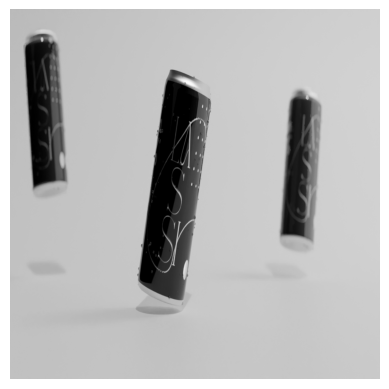

In [ ]:
from PIL import Image
from matplotlib import pyplot


img = Image.open('decoded_current.pgm')

pyplot.imshow(img, cmap='gray')
pyplot.axis('off')
pyplot.show()

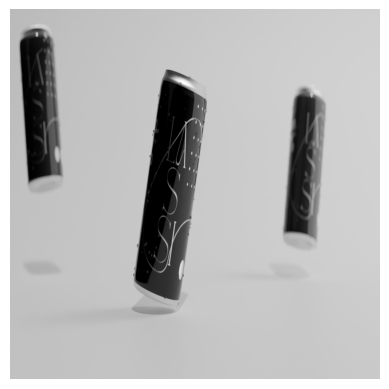

In [ ]:
img = Image.open('0021.png').convert('L').resize((HEIGHT, WIDTH))

pyplot.imshow(img, cmap='gray')
pyplot.axis('off')
pyplot.show()

**COMPRESSION AND DEDCOMPRESSION CODE**

not necessary to run but can be used to estimate the final output size

In [ ]:
import struct
import numpy as np
import zstandard as zstd
import os

# ============================================================
# Custom Bit-Level Writer
# ============================================================
class BitWriter:
    def __init__(self):
        self.buffer = bytearray()
        self.current_byte = 0
        self.bits_in_byte = 0

    def write_bits(self, value, num_bits):
        value = int(value) & ((1 << num_bits) - 1)
        for i in range(num_bits - 1, -1, -1):
            bit = (value >> i) & 1
            self.current_byte = (self.current_byte << 1) | bit
            self.bits_in_byte += 1

            if self.bits_in_byte == 8:
                self.buffer.append(self.current_byte)
                self.current_byte = 0
                self.bits_in_byte = 0

    def get_bytes(self):
        if self.bits_in_byte > 0:
            padded_byte = self.current_byte << (8 - self.bits_in_byte)
            self.buffer.append(padded_byte)
            self.bits_in_byte = 0
            self.current_byte = 0
        return bytes(self.buffer)

def float_to_fp16_bits(f_val):
    return int(np.float16(f_val).view(np.uint16))

# ============================================================
# Main Compressor Logic
# ============================================================
def compress_bitstream(input_file, output_file, width):
    print(f"Loading raw GPU bitstream: {input_file}")

    struct_fmt = "<HHHBBff16s"
    struct_size = struct.calcsize(struct_fmt)
    writer = BitWriter()


    codes = []

    grid_width = width // 4

    # 1. Read all blocks into memory
    with open(input_file, "rb") as f:
        while True:
            chunk = f.read(struct_size)
            if not chunk:
                break
            codes.append(struct.unpack(struct_fmt, chunk))

    total_codes_processed = len(codes)

    # 2. Geometric Sort (Top-to-Bottom, Left-to-Right)
    # This allows us to use Delta Coordinates instead of absolute 32-bit X/Y positions
    codes.sort(key=lambda c: (c[1], c[0]))

    skip_count = 0
    prev_x = 0
    prev_y = 0
    prev_idx = 0

    for data in codes:
        x, y = data[0], data[1]
        dom_idx = data[2]
        depth = data[3]
        iso = data[4]
        contrast = data[5]
        brightness = data[6]

        # This is now a single 16-byte raw object instead of 4 floats
        raw_pixels_bytes = data[7]
        # ------------------------------------------------
        # 1. RUN-LENGTH ENCODING FOR SKIPS
        # ------------------------------------------------
        if dom_idx == 0xFFFF:
            skip_count += 1
            continue

        if skip_count > 0:
            writer.write_bits(0xFFFF, 16)
            writer.write_bits(skip_count, 32)
            skip_count = 0

        # ------------------------------------------------
        # 2. VARIABLE-LENGTH 1D COORDINATES
        # ------------------------------------------------
        # Flatten the 1024x1024 screen into a 256x256 grid of 4x4 cells
        curr_idx = (y // 4) * grid_width + (x // 4)
        delta_idx = curr_idx - prev_idx
        prev_idx = curr_idx

        def write_coordinates():
            # If the block is close, write the jump in a single byte
            if delta_idx < 255:
                writer.write_bits(delta_idx, 8)
            # If the block is far, write an escape byte (255) followed by a 16-bit jump
            else:
                writer.write_bits(255, 8)
                writer.write_bits(delta_idx, 16)

        # ------------------------------------------------
        # 3. BYTE-ALIGNED MOTION VECTOR BLOCK
        # ------------------------------------------------
        if dom_idx == 0xFFFE:
            writer.write_bits(0xFFFE, 16)
            writer.write_bits(depth, 8)
            write_coordinates()

            writer.write_bits(int(contrast) + 128, 8)
            writer.write_bits(int(brightness) + 128, 8)

       # ------------------------------------------------
        # 4. BYTE-ALIGNED 4x4 RESIDUAL BLOCK
        # ------------------------------------------------
        elif dom_idx == 0xFFFD:
            writer.write_bits(0xFFFD, 16)
            writer.write_bits(depth, 8)
            write_coordinates()

            writer.write_bits(int(contrast) + 128, 8)
            writer.write_bits(int(brightness) + 128, 8)

            # Extract the 16 residuals directly from the raw bytes
            residuals = struct.unpack("<16b", raw_pixels_bytes)

            for res in residuals:
                writer.write_bits(res + 128, 8)

        # ------------------------------------------------
        # 5. BYTE-ALIGNED FRACTAL / RAW BLOCK
        # ------------------------------------------------
        else:
            writer.write_bits(dom_idx, 16)
            writer.write_bits(depth, 8)
            write_coordinates()

            writer.write_bits(iso, 8)
            writer.write_bits(float_to_fp16_bits(contrast), 16)
            writer.write_bits(float_to_fp16_bits(brightness), 16)

            if depth == 4:
                # If it's a raw block, convert the bytes back to 4 floats here
                raw_floats = struct.unpack("<4f", raw_pixels_bytes)
                for p_val in raw_floats:
                    writer.write_bits(float_to_fp16_bits(p_val), 16)


    # Catch remaining skips at end of frame
    if skip_count > 0:
        writer.write_bits(0xFFFF, 16)
        writer.write_bits(skip_count, 32)

    packed_bytes = writer.get_bytes()

    print(f"Packed bits into {len(packed_bytes)} bytes. Applying Zstd compression...")
    cctx = zstd.ZstdCompressor(level=15)
    compressed_data = cctx.compress(packed_bytes)

    with open(output_file, "wb") as f:
        f.write(compressed_data)

    original_size = os.path.getsize(input_file)
    final_size = len(compressed_data)
    reduction = (1.0 - (final_size / original_size)) * 100

    print("========================================")
    print(f"Total Blocks Read  : {total_codes_processed}")
    print(f"Original File Size : {original_size / 1024:.2f} KB")
    print(f"Final Packed Size  : {final_size / 1024:.2f} KB")
    print(f"Compression Ratio  : {reduction:.2f}% reduced")
    print("========================================")

if __name__ == "__main__":
    compress_bitstream("encoded_temporal.bin", "compressed_temporal.zst", WIDTH)

Loading raw GPU bitstream: encoded_temporal.bin
Packed bits into 295450 bytes. Applying Zstd compression...
Total Blocks Read  : 28243
Original File Size : 882.59 KB
Final Packed Size  : 151.91 KB
Compression Ratio  : 82.79% reduced


In [ ]:
import struct
import numpy as np
import zstandard as zstd

class BitReader:
    def __init__(self, data):
        self.data = data
        self.byte_pos = 0
        self.bit_pos = 7

    def read_bits(self, num_bits):
        value = 0
        for _ in range(num_bits):
            if self.byte_pos >= len(self.data):
                return None

            bit = (self.data[self.byte_pos] >> self.bit_pos) & 1
            value = (value << 1) | bit

            self.bit_pos -= 1
            if self.bit_pos < 0:
                self.bit_pos = 7
                self.byte_pos += 1
        return value

def fp16_bits_to_float(bits):
    return float(np.uint16(bits).view(np.float16))

def decompress_bitstream(input_file, output_file, width):
    print(f"Decompressing Zstd payload: {input_file}...")

    with open(input_file, "rb") as f:
        compressed_data = f.read()

    dctx = zstd.ZstdDecompressor()
    packed_bytes = dctx.decompress(compressed_data)

    reader = BitReader(packed_bytes)

    # Change 'ffff' to '16s' here as well
    struct_fmt = "<HHHBBff16s"


    codes = []
    prev_idx = 0
    total_skips = 0

    grid_width = width // 4

    print("Decoding bitstream into HybridCode structs...")
    while True:
        dom_idx = reader.read_bits(16)
        if dom_idx is None:
            break

        # ------------------------------------------------
        # 1. SKIP CODES (Counted but omitted from .bin)
        # ------------------------------------------------
        if dom_idx == 0xFFFF:
            skip_count = reader.read_bits(32)
            if skip_count is None:
                break
            total_skips += skip_count
            continue

        # ------------------------------------------------
        # 2. READ ALIGNED HEADER & DELTA COORDINATES
        # ------------------------------------------------
        depth = reader.read_bits(8)

        delta_idx = reader.read_bits(8)
        if delta_idx == 255:
            delta_idx = reader.read_bits(16)

        curr_idx = prev_idx + delta_idx
        prev_idx = curr_idx


        x = (curr_idx % grid_width) * 4
        y = (curr_idx // grid_width) * 4

        # ------------------------------------------------
        # 3. DECODE SPECIFIC PAYLOADS
        # ------------------------------------------------
        iso = 0
        contrast = 0.0
        brightness = 0.0
        f1, f2, f3, f4 = 0.0, 0.0, 0.0, 0.0

        if dom_idx == 0xFFFE: # Motion Vector
            contrast = float(reader.read_bits(8) - 128)
            brightness = float(reader.read_bits(8) - 128)

        elif dom_idx == 0xFFFD: # 4x4 Residual
            contrast = float(reader.read_bits(8) - 128)
            brightness = float(reader.read_bits(8) - 128)

            # FIX: Read 16 8-bit residuals to match the upgraded compressor
            res_ints = [(reader.read_bits(8) - 128) for _ in range(16)]

            # Pack back into 16 signed 8-bit integers, then unpack as 4 floats
            res_bytes = bytes([r & 0xFF for r in res_ints])
            f1, f2, f3, f4 = struct.unpack("<4f", res_bytes)

        else: # Fractal Block
            iso = reader.read_bits(8)
            contrast = fp16_bits_to_float(reader.read_bits(16))
            brightness = fp16_bits_to_float(reader.read_bits(16))

            if depth == 4: # Raw 2x2 Fallback
                f1 = fp16_bits_to_float(reader.read_bits(16))
                f2 = fp16_bits_to_float(reader.read_bits(16))
                f3 = fp16_bits_to_float(reader.read_bits(16))
                f4 = fp16_bits_to_float(reader.read_bits(16))


        raw_pixels_bytes = struct.pack("<4f", f1, f2, f3, f4)

        struct_bytes = struct.pack(struct_fmt,
            x, y, dom_idx, depth, iso,
            contrast, brightness,
            raw_pixels_bytes # Pass the raw bytes instead of f1, f2, f3, f4
        )
        codes.append(struct_bytes)

    # Write the binary output for CUDA
    with open(output_file, "wb") as f:
        for c in codes:
            f.write(c)

    print("========================================")
    print(f"Total Structural Blocks : {len(codes)}")
    print(f"Total Skipped Blocks    : {total_skips}")
    print(f"Wrote Decoded Output    : {output_file}")
    print("========================================")

if __name__ == "__main__":
    decompress_bitstream("compressed_temporal.zst", "encoded_temporal_decomressed.bin", WIDTH)

Decompressing Zstd payload: compressed_temporal.zst...
Decoding bitstream into HybridCode structs...
Total Structural Blocks : 23668
Total Skipped Blocks    : 4575
Wrote Decoded Output    : encoded_temporal_decomressed.bin


In [ ]:
!./decoder "0021.bin" "encoded_temporal_decomressed.bin" 1024 1024

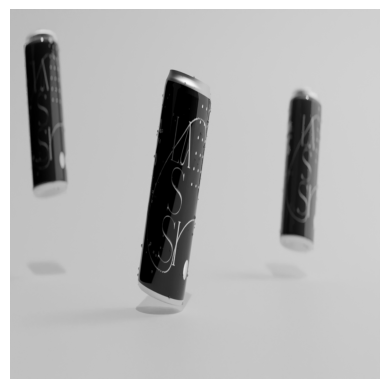

In [ ]:
img = Image.open('decoded_current.pgm')

pyplot.imshow(img, cmap='gray')
pyplot.axis('off')
pyplot.show()